# Stage 2 – Task 1 & Task 2: PCA và K-Means

**Mục tiêu:** dùng PCA để giảm số chiều dữ liệu và dùng K-Means để chia các dòng dữ liệu thành nhóm. Notebook này trình bày cả code, biểu đồ và phần nhận xét trực tiếp; không cần file report riêng.

Các bước chính:
1. Chọn đặc trưng phù hợp, mã hóa cột phân loại và chuẩn hóa dữ liệu.
2. Dùng PCA, xem **cumulative explained variance** và chọn số thành phần giữ ít nhất 85% phương sai.
3. Dùng Elbow Method (WCSS) và Silhouette Score để khảo sát số cụm K.
4. So sánh K-Means trên dữ liệu đã chuẩn hóa ban đầu và dữ liệu đã giảm chiều bằng PCA.
5. Vẽ cụm và thêm `Cluster_Label` vào dataset gốc.

> **Lưu ý:** K-Means là phương pháp học không giám sát, vì vậy `Cluster_Label` chỉ là mã nhóm do mô hình tạo ra, không phải nhãn đúng/sai có sẵn.

## 1. Import thư viện và đọc dữ liệu

Chỉ sử dụng các thư viện cơ bản thường học cùng Python Data Analysis và Machine Learning: `pandas`, `matplotlib`, và các công cụ từ `scikit-learn`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

df = pd.read_csv('eda_completed_master_dataset.csv')
# Dataset mới KHÔNG còn cột UnitPrice -> tạo lại từ cột Price (đơn giá 1 sản phẩm)
if "UnitPrice" not in df.columns:
    df["UnitPrice"] = df["Price"]
assert (df["TotalAmount"] == df["UnitPrice"] * df["Quantity"]).all(), "TotalAmount phải bằng UnitPrice x Quantity"

print(f"Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
print("\n5 dòng đầu tiên:")
display(df.head())

Kích thước dữ liệu: 1000 dòng, 20 cột

5 dòng đầu tiên:


,OrderID,CustomerID,CustomerName,Age,Gender,City,ProductID,Quantity,TotalAmount,PurchaseDate,PaymentMethod,ProductName,Brand,Category,Price,Rating,Source,Currency,Price_VND_ref,UnitPrice
0,ORD00001,C0214,Nguyễn Quốc Khoa,37,Nam,Hải Phòng,P10412,3,57000,2026-01-01,Ví điện tử,Bàn chải đánh răng trẻ em từ 2 đến 6 tuổi P/S ...,P/S,Bàn chải đánh răng,19000.0,4.88,Pharmacity_VN,VND,19000.0,19000.0
1,ORD00002,C0020,Trần Hữu Thành,18,Nam,Đà Nẵng,P18082,3,123000,2026-01-01,Thẻ ngân hàng,Kem Đánh Răng P/S Chăm Sóc Toàn Diện (tuýp 230g),P/S,Kem đánh răng,41000.0,4.92,Pharmacity_VN,VND,41000.0,41000.0
2,ORD00003,C0144,Bùi Thị Xuân,32,Nữ,TP. Hồ Chí Minh,P29620,1,194250,2026-01-01,Tiền mặt,Kem Đánh Răng Marvis Jasmin Mint Vị Hoa Nhài &...,Marvis,Kem đánh răng,194250.0,4.87,Pharmacity_VN,VND,194250.0,194250.0
3,ORD00004,C0253,Nguyễn Minh Huy,51,Nam,Hà Nội,P28349,1,110000,2026-01-02,COD,Nước súc miệng SMC Ag+ vệ sinh răng miệng (Cha...,Unknown,Nước súc miệng,110000.0,4.85,Pharmacity_VN,VND,110000.0,110000.0
4,ORD00005,C0138,Nguyễn Mỹ Dương,27,Nữ,Cần Thơ,P25083,3,37500,2026-01-02,Tiền mặt,Băng vệ sinh ban ngày siêu mỏng cánh Kotex Gar...,Kotex,Băng vệ sinh,12500.0,4.96,Pharmacity_VN,VND,12500.0,12500.0


### Nhận xét dữ liệu ban đầu

Dữ liệu có các cột định danh (ví dụ `OrderID`, `CustomerID`, `ProductID`), thông tin mô tả và thông tin giao dịch. Các mã ID hoặc tên riêng không nên đưa trực tiếp vào K-Means vì chúng không thể hiện khoảng cách hành vi có ý nghĩa.

Trong file này, số `CustomerID` duy nhất sẽ được kiểm tra bên dưới. Nếu mỗi khách hàng chỉ xuất hiện một lần, kết quả phân cụm thực tế phản ánh **các đơn hàng/bản ghi** nhiều hơn là hành vi mua lặp lại của khách hàng qua thời gian.

> **Cập nhật theo dataset mới:** file `eda_completed_master_dataset.csv` không còn cột `UnitPrice`. Vì `TotalAmount = Price × Quantity` đúng ở 100% dòng, notebook tạo lại `UnitPrice` từ cột `Price` để giữ nguyên các bước phía sau và các task dùng chung (Task 3, 4, 5).

In [2]:
print("Số CustomerID duy nhất:", df["CustomerID"].nunique())
print("Số OrderID duy nhất:", df["OrderID"].nunique())
print("Số dòng bị trùng hoàn toàn:", df.duplicated().sum())

Số CustomerID duy nhất: 350
Số OrderID duy nhất: 1000
Số dòng bị trùng hoàn toàn: 0


## 2. Chọn đặc trưng và chuẩn hóa

Để bài làm vừa đủ rõ ràng cho người mới học, notebook chọn:

- **Số:** `Age`, `UnitPrice`, `Quantity`, `TotalAmount`, `Rating`.
- **Phân loại:** `Gender`, `City`, `PaymentMethod`, `Category`. Các cột này sẽ được chuyển thành cột 0/1 bằng `pd.get_dummies()`.

Loại các cột ID/tên sản phẩm/tên khách hàng/ngày mua và các cột hằng hoặc trùng lặp như `Source`, `Currency`, `Price`, `Price_VND_ref` cùng các cột mã hóa sẵn. Điều này giúp tránh đưa mã định danh hoặc cùng một thông tin vào mô hình nhiều lần. `TotalAmount` và `UnitPrice` vẫn có liên hệ với nhau, nên kết quả cần được xem là phân tích khám phá đơn giản.

In [3]:
# Các đặc trưng được chọn cho phân cụm
numeric_features = ["Age", "UnitPrice", "Quantity", "TotalAmount", "Rating"]
categorical_features = ["Gender", "City", "PaymentMethod", "Category"]
selected_features = numeric_features + categorical_features

# Kiểm tra các cột cần dùng có tồn tại và có dữ liệu thiếu không
missing_columns = [col for col in selected_features if col not in df.columns]
if missing_columns:
    raise ValueError(f"Thiếu các cột cần thiết: {missing_columns}")

print("Số giá trị thiếu trong các cột được chọn:")
display(df[selected_features].isna().sum().to_frame("Missing values"))

# Dữ liệu được cung cấp không có giá trị thiếu ở các cột được chọn.
# Nếu có thiếu dữ liệu sau này, cần xử lý trước khi chạy PCA/K-Means.
if df[selected_features].isna().any().any():
    raise ValueError("Các cột đã chọn có giá trị thiếu; hãy xử lý missing values trước.")

# Mã hóa các cột phân loại thành nhiều cột 0/1
X = pd.get_dummies(
    df[selected_features],
    columns=categorical_features,
    drop_first=False,
    dtype=float
)

print("\nSố đặc trưng sau khi mã hóa:", X.shape[1])
print("Các đặc trưng được dùng (sau mã hóa):")
print(X.columns.tolist())

# Chuẩn hóa: đưa các đặc trưng về thang đo tương đương trước PCA/K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nKích thước ma trận sau chuẩn hóa:", X_scaled.shape)

Số giá trị thiếu trong các cột được chọn:


,Missing values
Age,0
UnitPrice,0
Quantity,0
TotalAmount,0
Rating,0
Gender,0
City,0
PaymentMethod,0
Category,0



Số đặc trưng sau khi mã hóa: 43
Các đặc trưng được dùng (sau mã hóa):
['Age', 'UnitPrice', 'Quantity', 'TotalAmount', 'Rating', 'Gender_Nam', 'Gender_Nữ', 'City_Cần Thơ', 'City_Hà Nội', 'City_Hải Phòng', 'City_TP. Hồ Chí Minh', 'City_Đà Nẵng', 'PaymentMethod_COD', 'PaymentMethod_Thẻ ngân hàng', 'PaymentMethod_Tiền mặt', 'PaymentMethod_Ví điện tử', 'Category_Bàn chải đánh răng', 'Category_Băng vệ sinh', 'Category_Chăm sóc da mặt cho nam', 'Category_Chăm sóc tóc cho nam', 'Category_Dao cạo râu & Bọt cạo râu', 'Category_Dung dịch vệ sinh phụ nữ', 'Category_Dưỡng thể & massage', 'Category_Dưỡng tóc', 'Category_Dầu gội đầu', 'Category_Dầu xả', 'Category_Hỗ trợ tẩy lông', 'Category_Kem đánh răng', 'Category_Khử mùi cho nam', 'Category_Lăn khử mùi', 'Category_Nhuộm tóc', 'Category_Nước rửa tay', 'Category_Nước súc miệng', 'Category_Sáp khử mùi', 'Category_Sản phẩm chăm sóc răng miệng khác', 'Category_Sản phẩm tắm & dưỡng thể cho nam', 'Category_Sản phẩm vệ sinh khác', 'Category_Sữa tắm', 'Ca

### Vì sao phải chuẩn hóa?

Ví dụ, `TotalAmount` có thể lên đến hàng triệu đồng, còn `Rating` chỉ nằm trong khoảng khoảng 4.5–5.0. Nếu không chuẩn hóa, các cột có số lớn có thể chi phối khoảng cách và phương sai. `StandardScaler()` chuyển các đặc trưng về thang đo có trung bình gần 0 và độ lệch chuẩn gần 1.

## Task 1 – PCA: giảm số chiều dữ liệu

Đầu tiên, chạy PCA để xem lượng phương sai tích lũy theo số thành phần. Theo đề bài, ta chọn **số thành phần nhỏ nhất giữ được ít nhất 85% phương sai** (nằm trong khoảng yêu cầu 85%–95%).

Số đặc trưng trước PCA: 43
Số thành phần PCA được chọn: 31
Phương sai tích lũy được giữ lại: 86.93%
Số chiều giảm được: 12


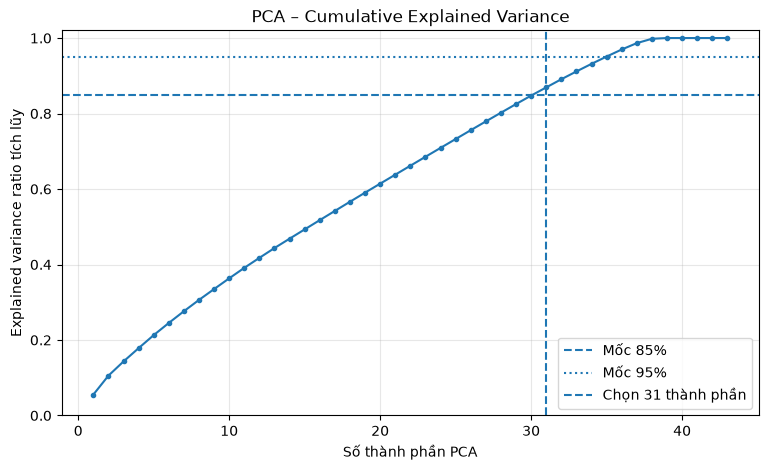

In [4]:
# Fit PCA đầy đủ để tính explained variance cho tất cả thành phần
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Chọn ít thành phần nhất để giữ >= 85% phương sai
variance_target = 0.85
n_components = int(np.argmax(cumulative_variance >= variance_target) + 1)
retained_variance = float(cumulative_variance[n_components - 1])

print(f"Số đặc trưng trước PCA: {X_scaled.shape[1]}")
print(f"Số thành phần PCA được chọn: {n_components}")
print(f"Phương sai tích lũy được giữ lại: {retained_variance:.2%}")
print(f"Số chiều giảm được: {X_scaled.shape[1] - n_components}")

plt.figure(figsize=(9, 5))
components_axis = np.arange(1, len(cumulative_variance) + 1)
plt.plot(components_axis, cumulative_variance, marker="o", markersize=3)
plt.axhline(0.85, linestyle="--", label="Mốc 85%")
plt.axhline(0.95, linestyle=":", label="Mốc 95%")
plt.axvline(n_components, linestyle="--", label=f"Chọn {n_components} thành phần")
plt.xlabel("Số thành phần PCA")
plt.ylabel("Explained variance ratio tích lũy")
plt.title("PCA – Cumulative Explained Variance")
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Nhận xét PCA

- Đường biểu diễn cho biết khi thêm các thành phần PCA thì phần phương sai được giữ lại tăng dần.
- Chọn điểm đầu tiên đạt mốc 85% giúp giữ phần lớn thông tin mà vẫn giảm số chiều.
- Nếu số thành phần được chọn vẫn chiếm phần lớn số đặc trưng ban đầu, việc giảm chiều là có nhưng chưa quá mạnh. Điều này có thể xảy ra vì dữ liệu có nhiều cột phân loại đã được mã hóa thành cột 0/1.
- PCA không tự chọn ra “những cột quan trọng nhất”; mỗi thành phần mới là sự kết hợp của các đặc trưng ban đầu.

Kích thước dữ liệu sau PCA: (1000, 31)
Phương sai tích lũy sau PCA: 86.93%


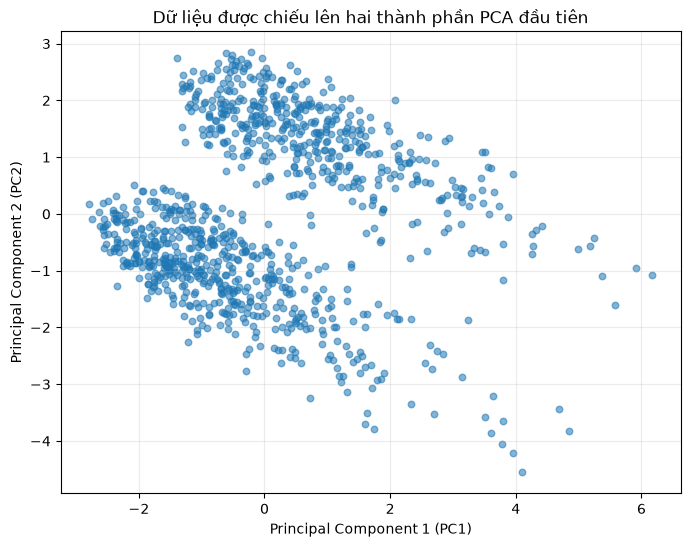

In [5]:
# Biến đổi dữ liệu sang không gian PCA đã chọn
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print("Kích thước dữ liệu sau PCA:", X_pca.shape)
print(f"Phương sai tích lũy sau PCA: {pca.explained_variance_ratio_.sum():.2%}")

# Vẽ hai thành phần đầu tiên để quan sát dữ liệu sau phép chiếu PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.55, s=22)
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("Dữ liệu được chiếu lên hai thành phần PCA đầu tiên")
plt.grid(alpha=0.25)
plt.show()

### Nhận xét biểu đồ PCA 2D

Biểu đồ chỉ hiển thị PC1 và PC2 để dễ quan sát; hai trục này không nhất thiết giữ toàn bộ thông tin của bộ dữ liệu. Các điểm chồng lấn nhau không có nghĩa PCA bị lỗi. Các điểm chỉ phân tách rõ nếu dữ liệu thực sự có cấu trúc dễ phân biệt trong hai chiều được vẽ.

## Task 2 – K-Means: chọn số cụm K

Dùng các giá trị K từ 2 đến 10 để khảo sát hai chỉ số:

- **WCSS / Inertia:** tổng bình phương khoảng cách từ điểm dữ liệu đến tâm cụm gần nhất. Chỉ số này thường giảm khi tăng K; tìm điểm “khuỷu tay” nơi mức giảm bắt đầu chậm lại.
- **Silhouette Score:** nằm trong khoảng -1 đến 1. Giá trị cao hơn thường biểu thị các cụm tách biệt tốt hơn; giá trị gần 0 cho thấy các cụm chồng lấn hoặc chưa rõ ràng.

Ta tính cả hai chỉ số trên dữ liệu chuẩn hóa ban đầu và dữ liệu sau PCA.

In [6]:
K_values = range(2, 11)
results = []

for k in K_values:
    # K-Means trên dữ liệu gốc đã chuẩn hóa
    model_original = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_original = model_original.fit_predict(X_scaled)
    silhouette_original = silhouette_score(X_scaled, labels_original)
    results.append({
        "Feature_Space": "Original scaled features",
        "K": k,
        "WCSS": model_original.inertia_,
        "Silhouette": silhouette_original
    })

    # K-Means trên dữ liệu đã giảm chiều bằng PCA
    model_pca = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_pca = model_pca.fit_predict(X_pca)
    silhouette_pca = silhouette_score(X_pca, labels_pca)
    results.append({
        "Feature_Space": "PCA-reduced features",
        "K": k,
        "WCSS": model_pca.inertia_,
        "Silhouette": silhouette_pca
    })

results_df = pd.DataFrame(results)
print("Bảng WCSS và Silhouette theo K:")
display(results_df.round(4))

Bảng WCSS và Silhouette theo K:


,Feature_Space,K,WCSS,Silhouette
0,Original scaled features,2,40894.5782,0.0571
1,PCA-reduced features,2,35300.1616,0.0643
2,Original scaled features,3,39716.1440,0.0526
3,PCA-reduced features,3,34148.0712,0.0612
4,Original scaled features,4,38734.9163,0.0651
5,PCA-reduced features,4,33202.2657,0.0679
6,Original scaled features,5,37788.1082,0.0383
7,PCA-reduced features,5,32322.4296,0.0788
8,Original scaled features,6,36783.3564,0.0632
9,PCA-reduced features,6,31577.7294,0.0679


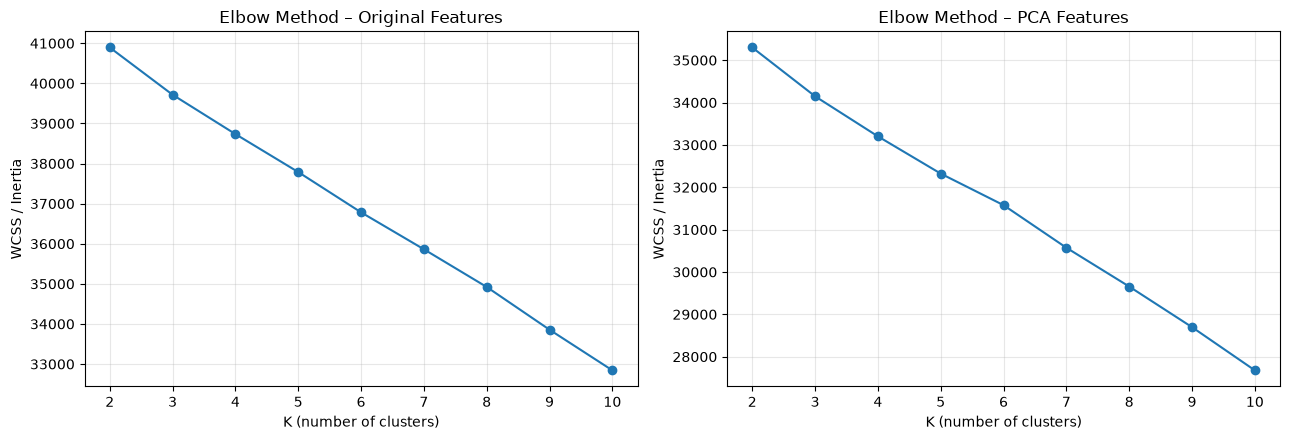

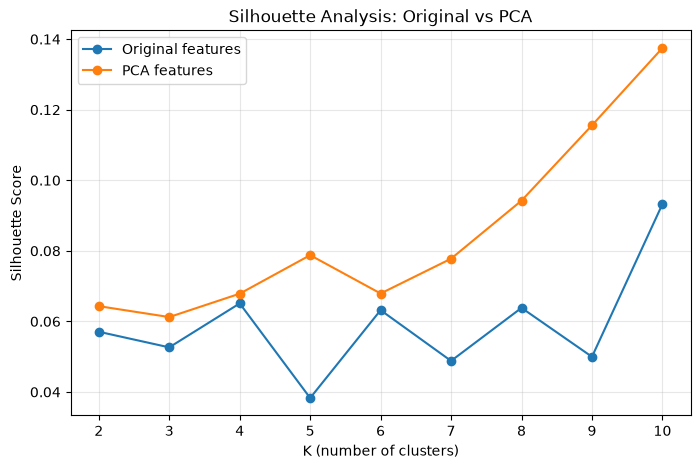

In [7]:
# Elbow plots: vẽ riêng từng không gian đặc trưng để dễ quan sát
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, space_name, title in [
    (axes[0], "Original scaled features", "Elbow Method – Original Features"),
    (axes[1], "PCA-reduced features", "Elbow Method – PCA Features")
]:
    part = results_df[results_df["Feature_Space"] == space_name]
    ax.plot(part["K"], part["WCSS"], marker="o")
    ax.set_xlabel("K (number of clusters)")
    ax.set_ylabel("WCSS / Inertia")
    ax.set_title(title)
    ax.set_xticks(list(K_values))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Silhouette plot so sánh hai không gian đặc trưng
plt.figure(figsize=(8, 5))
for space_name, legend_name in [
    ("Original scaled features", "Original features"),
    ("PCA-reduced features", "PCA features")
]:
    part = results_df[results_df["Feature_Space"] == space_name]
    plt.plot(part["K"], part["Silhouette"], marker="o", label=legend_name)

plt.xlabel("K (number of clusters)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis: Original vs PCA")
plt.xticks(list(K_values))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Cách đọc hai biểu đồ

1. **Elbow:** WCSS luôn có xu hướng giảm khi K tăng, nên không chỉ chọn K có WCSS nhỏ nhất. Cần xem đường cong có điểm gấp rõ hay không.
2. **Silhouette:** trong các K đã thử, giá trị lớn hơn là tín hiệu tốt hơn. Tuy nhiên, ngay cả K tốt nhất cũng có thể cho điểm thấp; điều này cho thấy dữ liệu chưa tạo thành các cụm tách biệt rõ.
3. Hai chỉ số có vai trò bổ sung cho nhau. Nếu Elbow không có “khuỷu tay” rõ, cần nêu điều đó thay vì khẳng định có một K hoàn hảo.

## So sánh mô hình tại K được chọn

Để có một quy tắc cụ thể và dễ giải thích, notebook chọn **K có Silhouette Score cao nhất trong không gian PCA với K từ 2 đến 10**. Sau đó, dùng đúng K đó cho cả hai không gian để việc so sánh nhất quán. Vì WCSS phụ thuộc vào số chiều và không gian khoảng cách, nên khi so sánh chất lượng phân cụm giữa hai không gian, ta chú ý nhiều hơn đến Silhouette Score và ý nghĩa thực tế của các nhóm.

In [8]:
# Chọn K theo silhouette cao nhất trong dữ liệu PCA, trong phạm vi K=2..10
pca_results = results_df[results_df["Feature_Space"] == "PCA-reduced features"]
best_pca_row = pca_results.loc[pca_results["Silhouette"].idxmax()]
best_k = int(best_pca_row["K"])

# Fit hai mô hình cuối cùng với cùng K
kmeans_original = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_original_final = kmeans_original.fit_predict(X_scaled)

kmeans_pca = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_pca_final = kmeans_pca.fit_predict(X_pca)

sil_original_final = silhouette_score(X_scaled, labels_original_final)
sil_pca_final = silhouette_score(X_pca, labels_pca_final)

comparison_df = pd.DataFrame({
    "Model": ["K-Means on original scaled features", "K-Means on PCA features"],
    "K": [best_k, best_k],
    "Number_of_features": [X_scaled.shape[1], X_pca.shape[1]],
    "WCSS": [kmeans_original.inertia_, kmeans_pca.inertia_],
    "Silhouette_Score": [sil_original_final, sil_pca_final]
})

print(f"K được chọn theo Silhouette trên PCA: {best_k}")
print("So sánh hai mô hình (dùng cùng K):")
display(comparison_df.round(4))

print("\nNhận xét tự động:")
if sil_pca_final > sil_original_final:
    print(f"- Trong phép thử này, PCA có Silhouette cao hơn ({sil_pca_final:.3f}) so với dữ liệu gốc ({sil_original_final:.3f}).")
    print("- Điều đó gợi ý các cụm tách biệt hơn một chút trong không gian PCA, nhưng chưa đủ để khẳng định chất lượng phân cụm là tốt.")
elif sil_pca_final < sil_original_final:
    print(f"- Trong phép thử này, dữ liệu gốc có Silhouette cao hơn ({sil_original_final:.3f}) so với PCA ({sil_pca_final:.3f}).")
    print("- Giảm chiều có thể đã bỏ bớt một phần thông tin hữu ích cho việc phân cụm.")
else:
    print("- Hai mô hình có Silhouette gần như bằng nhau trong phép thử này.")

if max(sil_original_final, sil_pca_final) < 0.25:
    print("- Cả hai điểm Silhouette đều thấp (dưới 0.25): các cụm có khả năng chồng lấn nhiều, nên xem đây là kết quả khám phá chứ chưa phải các phân khúc thật sự rõ ràng.")

if best_k == max(K_values):
    print("- K được chọn nằm ở giới hạn trên của khoảng đã thử. Có thể thử thêm K lớn hơn trong một lần phân tích tiếp theo, nhưng cần cân nhắc việc tạo quá nhiều nhóm nhỏ.")

K được chọn theo Silhouette trên PCA: 10
So sánh hai mô hình (dùng cùng K):


,Model,K,Number_of_features,WCSS,Silhouette_Score
0,K-Means on original scaled features,10,43,32842.7009,0.0932
1,K-Means on PCA features,10,31,27677.8711,0.1375



Nhận xét tự động:
- Trong phép thử này, PCA có Silhouette cao hơn (0.137) so với dữ liệu gốc (0.093).
- Điều đó gợi ý các cụm tách biệt hơn một chút trong không gian PCA, nhưng chưa đủ để khẳng định chất lượng phân cụm là tốt.
- Cả hai điểm Silhouette đều thấp (dưới 0.25): các cụm có khả năng chồng lấn nhiều, nên xem đây là kết quả khám phá chứ chưa phải các phân khúc thật sự rõ ràng.
- K được chọn nằm ở giới hạn trên của khoảng đã thử. Có thể thử thêm K lớn hơn trong một lần phân tích tiếp theo, nhưng cần cân nhắc việc tạo quá nhiều nhóm nhỏ.


### Nhận xét so sánh PCA và dữ liệu gốc

- Nếu Silhouette của PCA cao hơn, dữ liệu sau giảm chiều có vẻ tách nhóm tốt hơn **theo chỉ số này** trong lần chạy hiện tại.
- Không nên kết luận chỉ dựa vào WCSS tuyệt đối: số chiều khác nhau khiến WCSS của hai không gian không thể so sánh trực tiếp một cách công bằng.
- Silhouette thấp là một phát hiện quan trọng, không phải lỗi code. Có thể các đặc trưng hiện có chưa đủ để tách các nhóm mua hàng thật sự rõ ràng.
- K được chọn là tốt nhất trong **phạm vi K đã thử**, không có nghĩa đó là số cụm tối ưu tuyệt đối cho mọi cách chọn đặc trưng.

## Biểu đồ phân cụm

Màu sắc bên dưới thể hiện nhãn cụm do K-Means chạy trên dữ liệu PCA tạo ra. Biểu đồ dùng PC1 và PC2 để hiển thị 2D, dù mô hình phân cụm đã sử dụng toàn bộ các thành phần PCA được chọn.

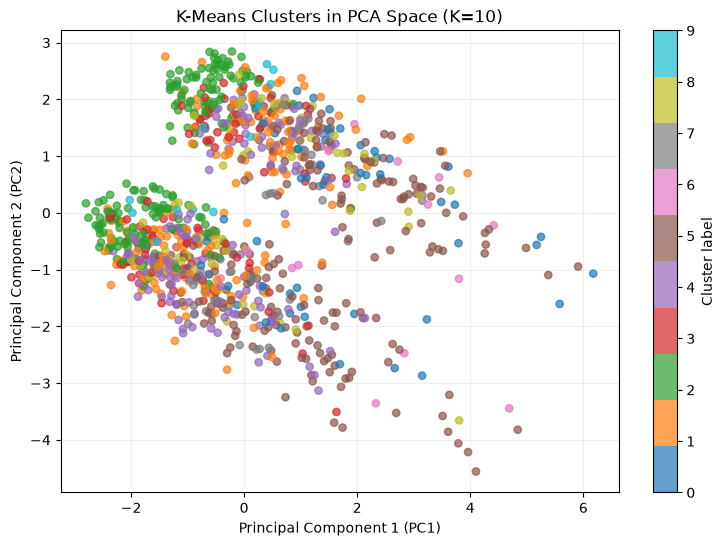

In [9]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=labels_pca_final,
    cmap="tab10",
    alpha=0.7,
    s=28
)
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title(f"K-Means Clusters in PCA Space (K={best_k})")
plt.colorbar(scatter, label="Cluster label")
plt.grid(alpha=0.2)
plt.show()

### Nhận xét biểu đồ phân cụm

Màu gần nhau trên biểu đồ tương ứng cùng một cụm, nhưng nhãn 0, 1, 2, ... chỉ là tên nhóm và không mang ý nghĩa xếp hạng. Vì hình chỉ chiếu dữ liệu về hai chiều, một số nhóm có thể chồng lấn trên hình dù khoảng cách trong không gian PCA đầy đủ khác nhau.

## Thêm `Cluster_Label` vào dataset gốc

Theo yêu cầu đề bài, ta đưa nhãn phân cụm trở lại từng dòng dữ liệu ban đầu. Notebook chọn nhãn của mô hình K-Means chạy trên dữ liệu PCA. Sau đó hiển thị số lượng bản ghi mỗi cụm và một số thống kê đơn giản để hỗ trợ diễn giải.

In [10]:
# Sao chép dataset gốc để giữ nguyên các cột ban đầu và thêm Cluster_Label
df_with_clusters = df.copy()
df_with_clusters["Cluster_Label"] = labels_pca_final

print("5 dòng đầu sau khi thêm Cluster_Label:")
display(df_with_clusters[["OrderID", "CustomerID", "Age", "Category", "UnitPrice", "Quantity", "TotalAmount", "Cluster_Label"]].head())

print("\nSố lượng bản ghi theo cụm:")
cluster_counts = df_with_clusters["Cluster_Label"].value_counts().sort_index().to_frame("Number_of_rows")
display(cluster_counts)

print("\nThống kê một số đặc trưng số theo cụm:")
cluster_profile = df_with_clusters.groupby("Cluster_Label")[
    ["Age", "UnitPrice", "Quantity", "TotalAmount", "Rating"]
].mean().round(2)
display(cluster_profile)

5 dòng đầu sau khi thêm Cluster_Label:


,OrderID,CustomerID,Age,Category,UnitPrice,Quantity,TotalAmount,Cluster_Label
0,ORD00001,C0214,37,Bàn chải đánh răng,19000.0,3,57000,3
1,ORD00002,C0020,18,Kem đánh răng,41000.0,3,123000,4
2,ORD00003,C0144,32,Kem đánh răng,194250.0,1,194250,4
3,ORD00004,C0253,51,Nước súc miệng,110000.0,1,110000,8
4,ORD00005,C0138,27,Băng vệ sinh,12500.0,3,37500,2



Số lượng bản ghi theo cụm:


,Number_of_rows
Cluster_Label,
0,57
1,158
2,192
3,90
4,146
5,201
6,15
7,58
8,70



Thống kê một số đặc trưng số theo cụm:


,Age,UnitPrice,Quantity,TotalAmount,Rating
Cluster_Label,,,,,
0,29.04,134136.84,1.98,289116.84,4.73
1,30.81,75115.51,1.94,143431.39,4.72
2,31.58,34948.23,1.90,66417.19,4.79
3,31.72,58082.78,2.10,121463.89,4.75
4,29.73,88434.93,1.69,141870.92,4.75
5,30.33,150305.07,1.89,286583.88,4.79
6,29.80,163453.33,2.07,330266.67,4.72
7,29.86,110433.10,1.64,182152.76,4.76
8,29.07,87734.29,1.97,182870.71,4.77


### Cách diễn giải bảng thống kê cụm

So sánh trung bình `Age`, `UnitPrice`, `Quantity`, `TotalAmount` và `Rating` giữa các cụm để thấy nhóm nào có đơn hàng giá trị cao hơn, số lượng sản phẩm nhiều hơn hoặc khách hàng có độ tuổi trung bình khác nhau. Đây chỉ là mô tả ban đầu; không nên gán tên như “khách hàng trung thành” hoặc “khách hàng cao cấp” vì dữ liệu hiện tại không có lịch sử mua lặp lại hay nhãn xác nhận những khái niệm đó.

In [11]:
# Lưu dataset gốc kèm nhãn cụm thành CSV để nhóm có thể dùng ở các task tiếp theo
output_path = Path("master_dataset_with_cluster_labels.csv")
# Thêm các cột mã hóa 0/1 (Gender, PaymentMethod) để Task 4 dùng trực tiếp; Cluster_Label đặt cuối
dummies = pd.get_dummies(df_with_clusters[["Gender", "PaymentMethod"]], drop_first=True, dtype=bool)
cols = [c for c in df_with_clusters.columns if c != "Cluster_Label"]
df_to_save = pd.concat([df_with_clusters[cols], dummies, df_with_clusters[["Cluster_Label"]]], axis=1)
df_to_save.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu dataset kèm Cluster_Label tại: {output_path.resolve()}")

Đã lưu dataset kèm Cluster_Label tại: C:\Users\LOQ\Downloads\Group5_Pharmacity_Personal_Care-main\Group5_Pharmacity_Personal_Care-main\Stage 2\master_dataset_with_cluster_labels.csv


## Kết luận chung cho Task 1 và Task 2

**Task 1 – PCA:** đã chuẩn hóa đặc trưng, tính cumulative explained variance, chọn số thành phần nhỏ nhất đạt ít nhất 85% phương sai và vẽ biểu đồ phương sai tích lũy cùng biểu đồ chiếu PCA 2D.

**Task 2 – K-Means:** đã khảo sát K từ 2 đến 10 bằng Elbow Method và Silhouette Score trên cả dữ liệu ban đầu đã chuẩn hóa và dữ liệu PCA. Sau khi chọn K theo Silhouette trong phạm vi thử nghiệm, notebook so sánh hai không gian, vẽ biểu đồ cụm và thêm `Cluster_Label` vào dữ liệu gốc.

**Giới hạn cần nêu khi thuyết trình:** nếu Silhouette Score thấp và Elbow không có điểm gấp rõ, dữ liệu chưa có bằng chứng mạnh về những cụm tách biệt tốt. Ngoài ra, dataset hiện có 1000 đơn nhưng chỉ 350 `CustomerID` duy nhất (một khách có thể mua nhiều đơn), nên K-Means ở đây vẫn đang phân cụm **từng đơn hàng**, chưa phải từng khách hàng. Muốn phân khúc khách hàng đúng nghĩa hơn thì nên tổng hợp dữ liệu theo `CustomerID` (tổng chi tiêu, số đơn, số lượng trung bình...) trước khi phân cụm. Ngoài ra Silhouette cao nhất rơi vào K = 10 (cận trên của khoảng thử) và điểm vẫn thấp, nên cần nêu rõ đây là kết quả khám phá.